# E1 · CLIP ViT-B/32 sobre la imagen completa (línea base)

**Pregunta.** ¿Un encoder visual preentrenado, sin ningún ajuste, ya ordena correctamente a la mascota buscada entre las de su especie?

| | |
|---|---|
| Pipeline | imagen completa → CLIP ViT-B/32 (OpenAI, revisión fija `3d74acf9`) → vector de 512 dimensiones, norma L2 |
| Entrenamiento | ninguno (*zero-shot*) |
| Modelo | `pettrace-embedder` versión 1 (`clip-vit-b32@v1`), en producción en la app |
| Dataset | `pettrace-reid@v3` (privado en Hugging Face; animales con códigos seudónimos, sin fotos en este notebook) |
| Protocolo | cada foto es una consulta; galería = las demás fotos de la misma especie (*leave-one-out*); cada animal puntúa con su mejor foto; Rank-1/5/10, mAP, EER |

Reproducir: `make image && make notebook NB=notebooks/e1_clip_zero_shot.ipynb` (ver el README). El notebook registra una ejecución en MLflow con el commit del código, el commit del dataset y el sha256 del modelo, y adjunta figuras, tablas y este mismo notebook.

In [1]:
import json, os

# Paths are relative to the repository root (nbconvert starts the kernel in notebooks/).
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR", "false")
os.environ.setdefault("TQDM_DISABLE", "1")
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
from collections import Counter

from IPython.display import Image, Markdown, display

from reid import data
from reid.evaluation import evaluate, load_model, log_run, report
from reid.figures import explain, metrics_table, save

print("código  :", os.environ.get("GIT_SHA", "?")[:7], "(sin cambios locales)" if os.environ.get("GIT_DIRTY") == "false" else "(¡cambios sin commit!)")
print("MLflow  :", os.environ.get("MLFLOW_TRACKING_URI"))

EXPERIMENT, DATASET, MODEL, REPORT = "E1", "v3", "models:/pettrace-embedder/1", "reports/e1_v3"

código  : a9b9644 (sin cambios locales)
MLflow  : https://mlflow.chumpitaz.dev


## 1. Datos

In [2]:
ds = data.load(DATASET)
bucket = lambda x: "oscura" if x < 0.25 else "tenue" if x < 0.4 else "normal"
rows = ["| Especie | Animales | Fotos | Fotos por animal | Luz normal / tenue / oscura | Particiones |", "|---|---|---|---|---|---|"]
for sp in ("cat", "dog"):
    ph = [p for p in ds.photos if p.species == sp]
    per = Counter(p.animal for p in ph)
    light = Counter(bucket(p.light) for p in ph)
    splits = Counter(ds.animals[a]["split"] for a in per)
    rows.append(f"| {sp} | {len(per)} | {len(ph)} | {min(per.values())}–{max(per.values())} | "
                f"{light['normal']} / {light['tenue']} / {light['oscura']} | {dict(splits)} |")
display(Markdown(f"**{ds.name}** · commit `{ds.commit}` · huella `{ds.fingerprint}`\n\n" + "\n".join(rows)))
groups = Counter(r["lookalike_group"] for r in ds.animals.values() if r["lookalike_group"])
display(Markdown("Grupos de parecido (negativos difíciles): " + ", ".join(
    f"`{g}`: " + ", ".join(a for a, r in sorted(ds.animals.items()) if r["lookalike_group"] == g) for g in sorted(groups))))

**pettrace-reid@v3** · commit `354763693e9105eb953c559620037dd98995326b` · huella `1bd0c64aea5b64d9`

| Especie | Animales | Fotos | Fotos por animal | Luz normal / tenue / oscura | Particiones |
|---|---|---|---|---|---|
| cat | 7 | 61 | 5–10 | 46 / 10 / 5 | {'test': 7} |
| dog | 7 | 67 | 6–12 | 53 / 13 / 1 | {'test': 7} |

Grupos de parecido (negativos difíciles): `orange-white-1`: cat-04, cat-06, `shiba-1`: dog-05, dog-06, `tabby-1`: cat-01, cat-02, `white-curly-1`: dog-01, dog-02

## 2. Modelo

Se descarga la versión registrada y se verifica que es el modelo que dice ser: el *golden set* (12 imágenes generadas) re-embebido con su propio pipeline debe coincidir con los embeddings guardados al registrarla.

In [3]:
model = load_model(MODEL)
display(Markdown("\n".join([
    "| | |", "|---|---|",
    f"| URI | `{model.uri}` (versión {model.registry_version} del registro) |",
    f"| Pipeline | `{model.model_version}` |",
    *[f"| sha256 `{f}` | `{h}` |" for f, h in model.sha256.items()],
    f"| Golden set | huella `{model.golden_fingerprint}`, {'✓ reproduce los embeddings guardados' if model.golden_ok else '✗ NO coincide'} |",
])))
assert model.golden_ok, "the downloaded model does not reproduce its golden fingerprint"

| | |
|---|---|
| URI | `models:/pettrace-embedder/1` (versión 1 del registro) |
| Pipeline | `clip-vit-b32@v1` |
| sha256 `encoder.onnx` | `4773e649274ca8774c4a63d45f0438fe598ee7ba67e65def97537aa0eca9a576` |
| Golden set | huella `5e40c7774bd7ad51`, ✓ reproduce los embeddings guardados |

## 3. Entrenamiento

No aplica: E1 es la línea base *zero-shot*. El encoder se usa tal como fue preentrenado.

## 4. Evaluación

In [4]:
ev = evaluate(ds, model.pipeline, zero_shot=True)
print(report(ev.result))

pettrace-reid@v3
group    queries gallery  Rank-1  Rank-5 Rank-10     mAP
global       128       7   73.4%   98.4%  100.0%   0.509
cat           61       7   75.4%   98.4%  100.0%   0.569
dog           67       7   71.6%   98.5%  100.0%   0.453
EER on all pairs (optimistic) 39.2% at threshold 0.794 → FAR 39.2%, FRR 39.2%


## 5. Resultados

In [5]:
s1 = save(ev, model, REPORT)
display(Markdown(metrics_table({"E1": s1})))

| Métrica | E1 |
|---|---|
| Consultas / galería por especie | 128 / 7 animales |
| Rank-1 global (azar 14.3 %) | **73.4 %** |
| Rank-1 gatos / perros | 75.4 % / 71.6 % |
| Rank-5 global (azar 71.4 %) | 98.4 % |
| mAP global | 0.509 |
| mAP gatos / perros | 0.569 / 0.453 |
| EER / umbral | 39.2 % / 0.794 |
| Similitud mínima, mismo animal | 0.548 |
| Similitud máxima, distinto animal | 0.949 |

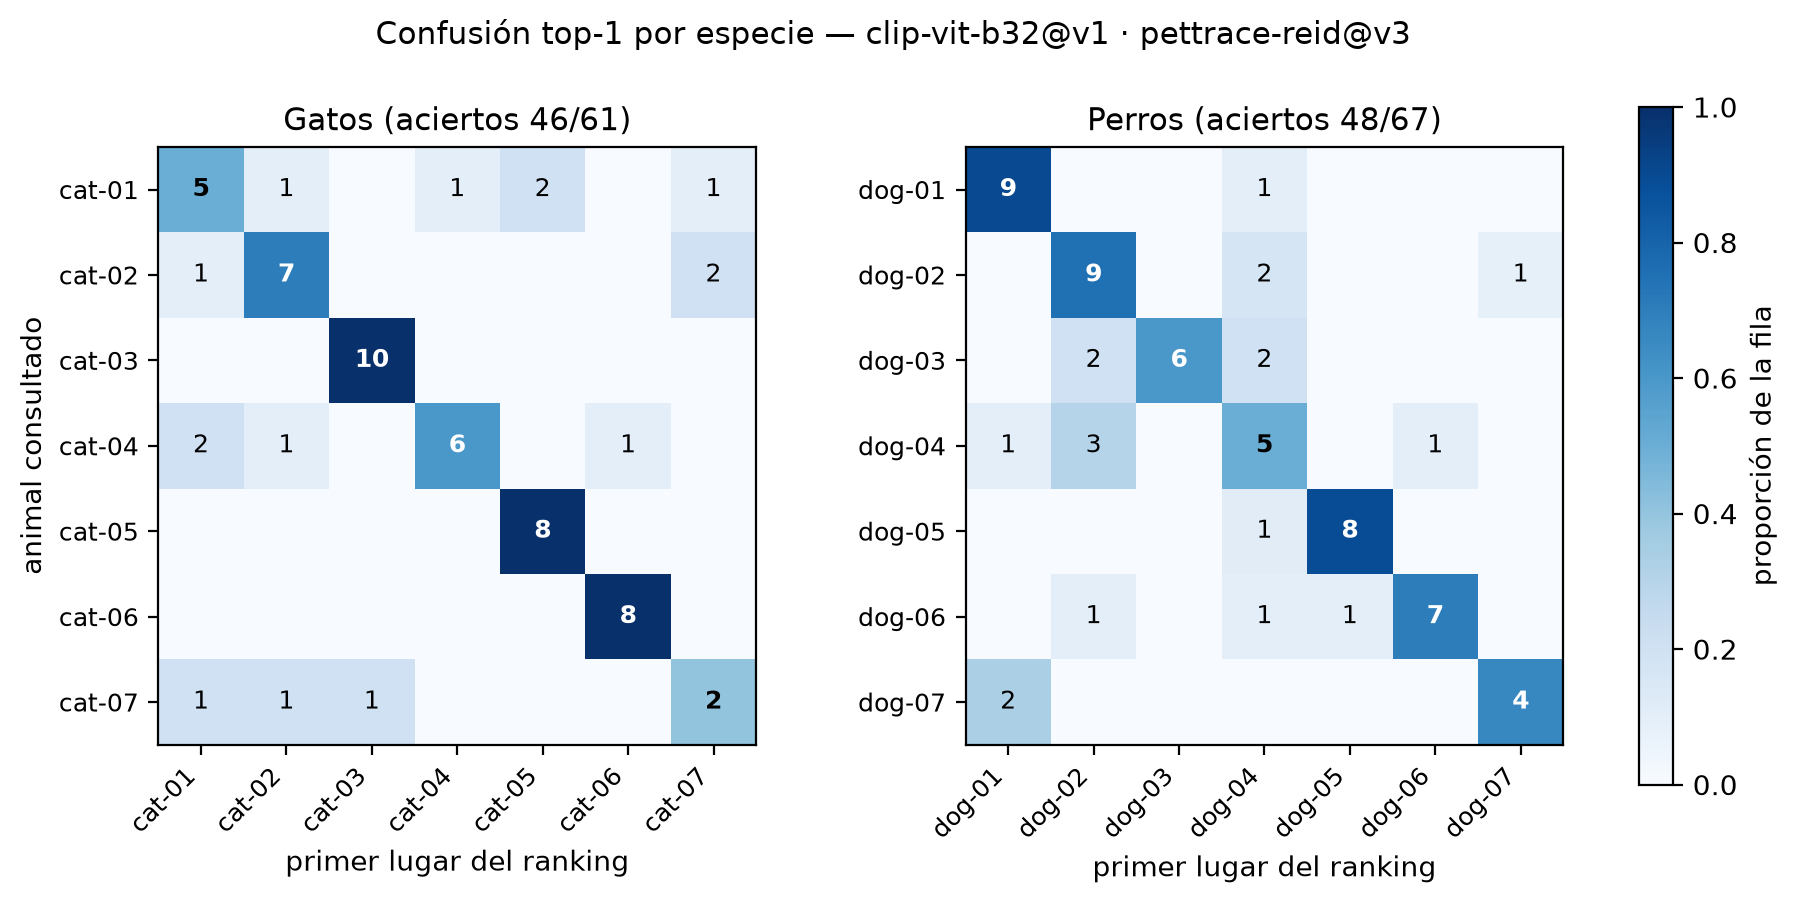

**Cómo leerlo.** Cada fila es el animal consultado y cada columna el animal que el modelo puso en primer lugar; el número es la cantidad de consultas. La diagonal son los aciertos y todo lo que queda fuera de ella son confusiones; solo se compara dentro de cada especie, como en la app. **En esta ejecución** acierta 46/61 en gatos y 48/67 en perros. Las confusiones más frecuentes: `dog-04` → `dog-02` (3 de 10), `dog-07` → `dog-01` (2 de 6) y `dog-03` → `dog-04` (2 de 10). Si se concentran dentro de un grupo de parecido, el error es de pelaje similar y no del método.

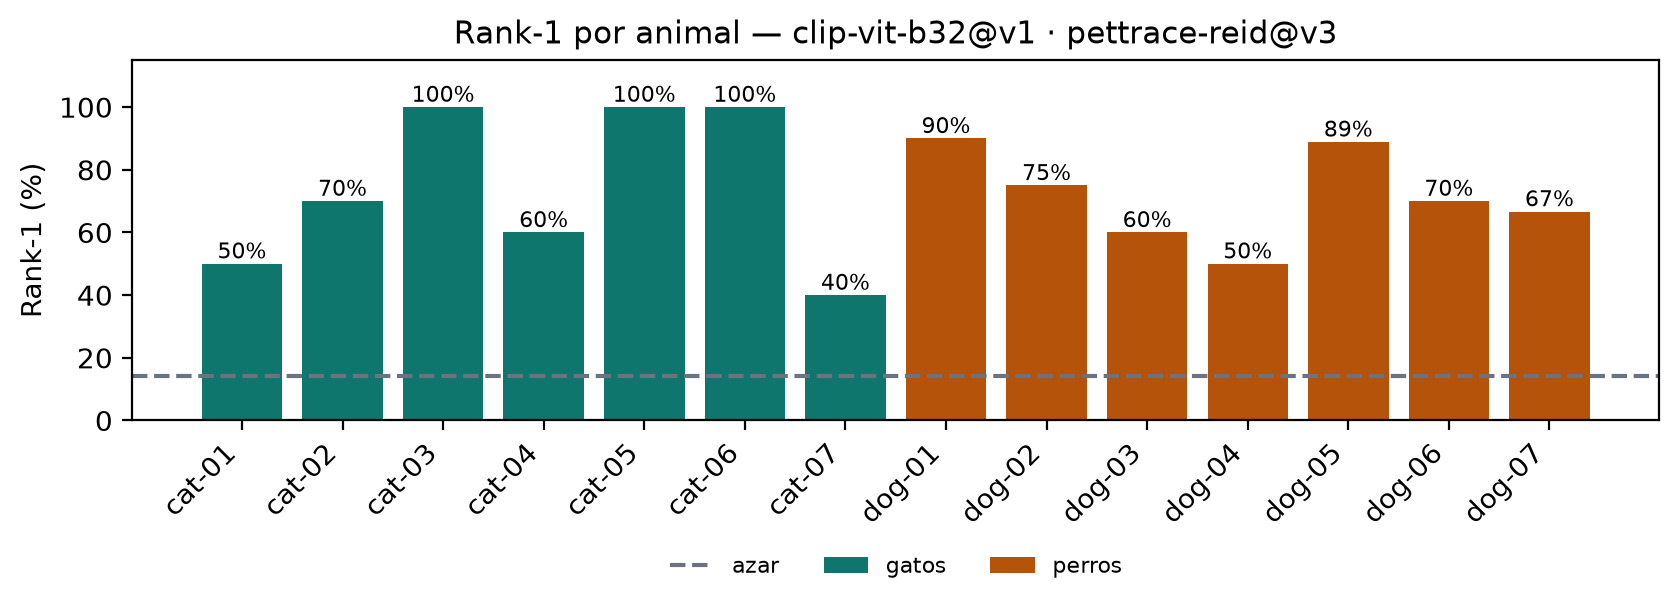

**Cómo leerlo.** Cada barra es el porcentaje de consultas de ese animal en que el animal correcto quedó primero; la línea punteada es el azar (14.3% con 7 animales por especie). Muestra si el promedio esconde animales mucho más difíciles que otros. **En esta ejecución** `cat-03`, `cat-05` y `cat-06` aciertan todas sus consultas y los más difíciles son `cat-07` (2/5), `cat-01` (5/10) y `dog-04` (5/10).

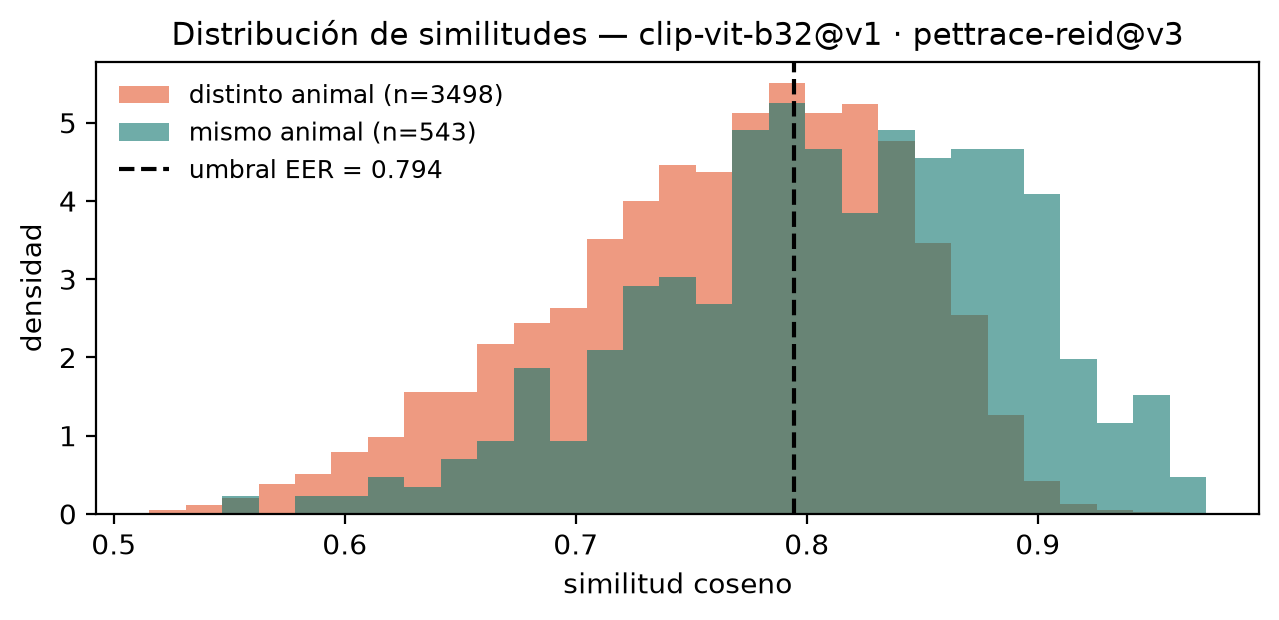

**Cómo leerlo.** Histogramas de la similitud coseno entre pares de fotos del mismo animal (verde) y de animales distintos de la misma especie (rojo); la línea punteada es el umbral donde ambos errores se igualan (EER). Cuanto menos se solapan, mejor separa el modelo identidades con un umbral fijo. **En esta ejecución** la EER es 39.2% con umbral 0.794: pares del mismo animal van de 0.548 a 0.973 y de animales distintos de 0.515 a 0.949, así que un umbral fijo no basta y el producto muestra un ranking que el dueño confirma.

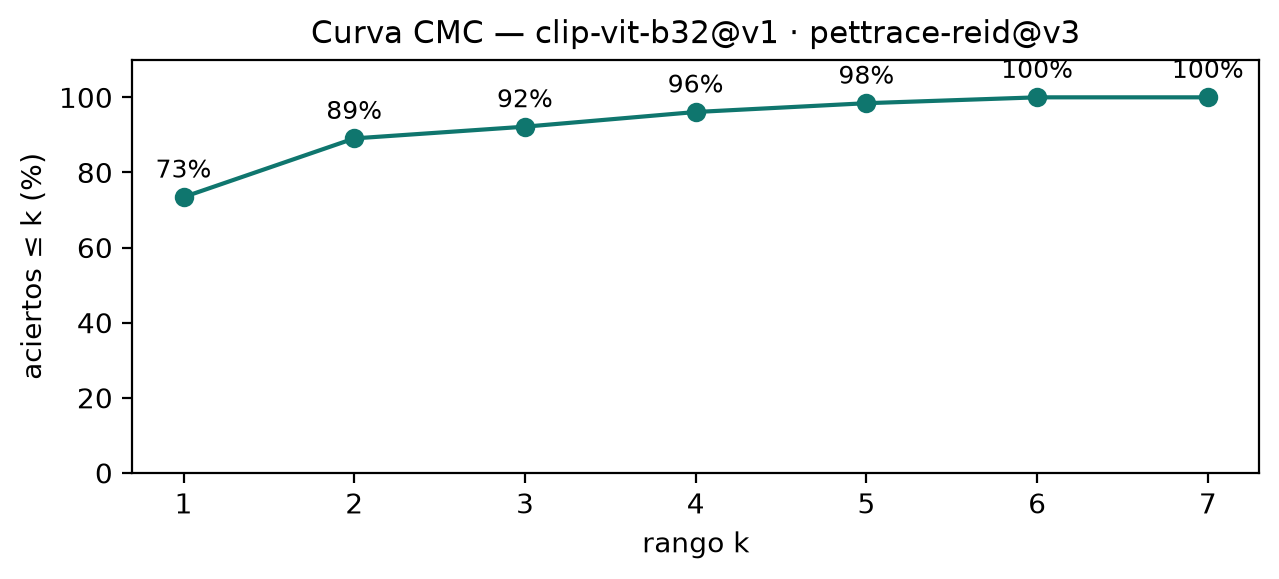

**Cómo leerlo.** Curva CMC: para cada k, el porcentaje de consultas en que el animal correcto aparece entre los k primeros del ranking. Es lo que ve el dueño: cuántos candidatos debe revisar. Con 7 animales por especie, en k = 7 siempre es 100 %. **En esta ejecución** el correcto está primero en 73.4% de las consultas (azar 14.3%) y entre los 5 primeros en 98.4% (azar 71.4%).

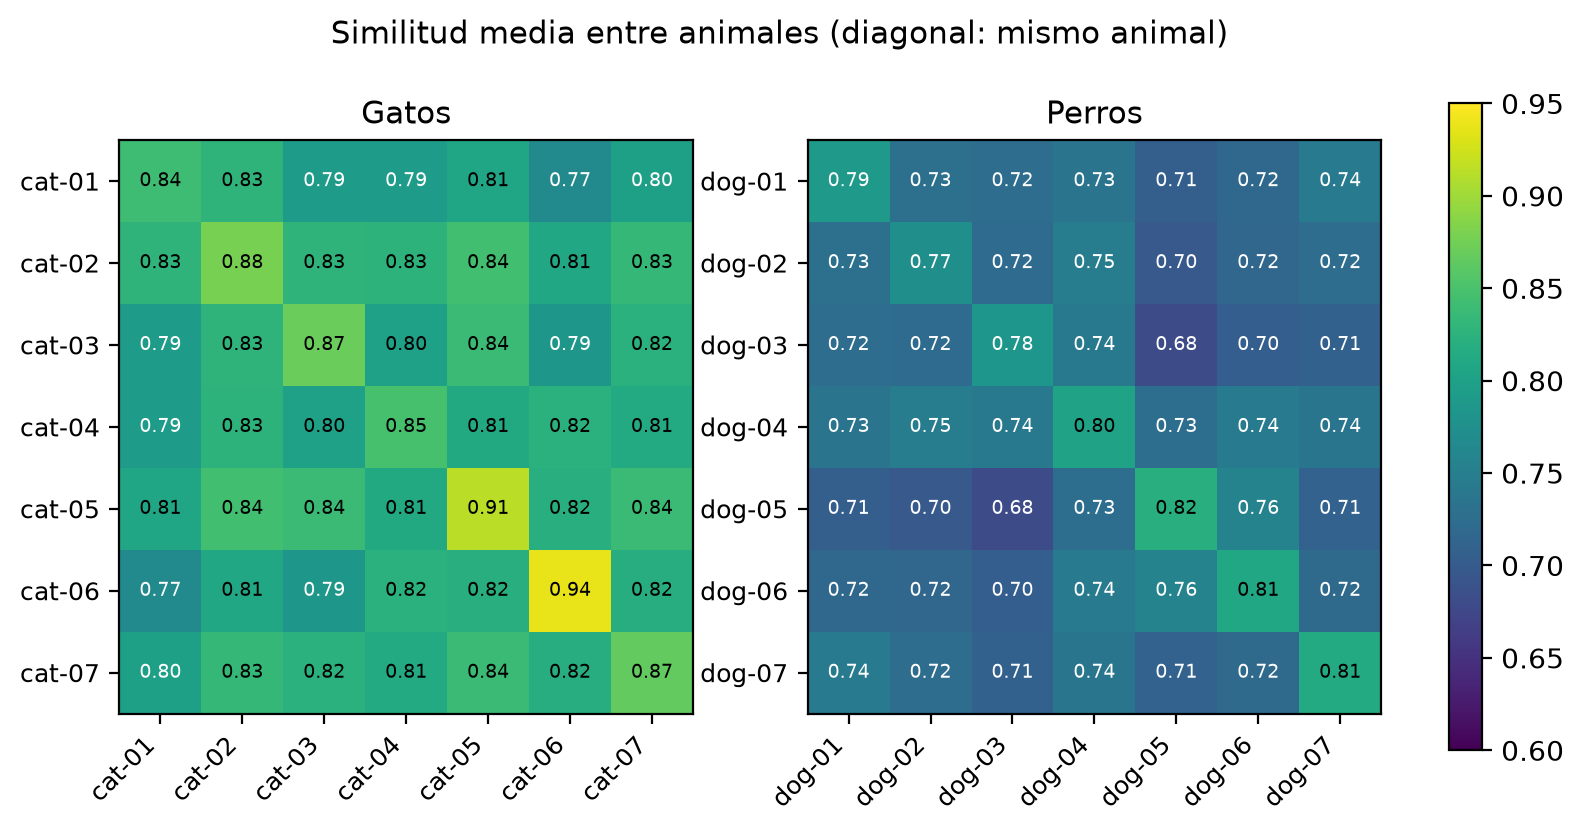

**Cómo leerlo.** Similitud coseno media entre las fotos de cada par de animales; la diagonal es el mismo animal. Una diagonal clara sobre un fondo oscuro indica que el embedding agrupa por identidad; celdas claras fuera de la diagonal señalan animales que el modelo ve parecidos. **En esta ejecución** la similitud media es en gatos 0.859 (mismo) frente a 0.813 (distinto); en perros 0.772 (mismo) frente a 0.724 (distinto): la diferencia es pequeña, por eso el ranking funciona pero un umbral fijo no.

In [6]:
summ = json.load(open(os.path.join(REPORT, "summary.json")))
for name in ("confusion", "rank1_por_animal", "distribucion_scores", "cmc", "matriz_similitud"):
    display(Image(os.path.join(REPORT, f"{name}.png"), width=760))
    display(Markdown(explain(name, summ)))

## 6. Registro en MLflow

In [7]:
run_id = log_run(ev, model, experiment=EXPERIMENT, artifacts=REPORT)
json.dump({"run_id": run_id, "experiment": EXPERIMENT, "dataset": ds.name, "dataset_commit": ds.commit,
           "model": MODEL, "git_sha": os.environ.get("GIT_SHA", "unknown")}, open(os.path.join(REPORT, "run.json"), "w"), indent=2)
display(Markdown(f"Ejecución MLflow: [`{run_id[:8]}`]({os.environ['MLFLOW_TRACKING_URI']}/#/experiments/"
                 f"{__import__('mlflow').get_experiment_by_name('pettrace-reid-eval').experiment_id}/runs/{run_id})"))

🏃 View run E1 · clip-vit-b32@v1 on pettrace-reid@v3 at: https://mlflow.chumpitaz.dev/#/experiments/3/runs/8098d8c49c0448fe93282565a2202af6
🧪 View experiment at: https://mlflow.chumpitaz.dev/#/experiments/3


Ejecución MLflow: [`8098d8c4`](https://mlflow.chumpitaz.dev/#/experiments/3/runs/8098d8c49c0448fe93282565a2202af6)

## 7. Conclusiones

- **El ranking funciona muy por encima del azar**: el animal correcto queda primero en ~73 % de las consultas frente a 14 % por azar, y casi siempre está entre los 5 primeros. Es la base de la decisión de producto: mostrar un *ranking* que el dueño confirma.
- **Un umbral fijo no separa identidades**: las similitudes de pares de animales distintos llegan a valores tan altos como las del mismo animal (EER ≈ 39 %). No se usan alertas automáticas por umbral.
- **Los errores se concentran en los grupos de parecido** (atigrados, blancos de pelo rizado), lo que motiva E2 (quitar el fondo) y E3–E5 (especializar con el dataset propio y con la descripción).
- Muestra pequeña (14 animales, 128 consultas): los resultados se leen como tendencia; los intervalos de confianza están pendientes (ver `TODO.md`).